# Plant Leaf Disease Detection using Deep Learning

## Mounting Google Drive and Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/Major Project/Final Dataset" /content/


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi


Sat Apr  4 05:13:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Importing Required Libraries

In [ ]:

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import shutil
import cv2
from random import sample, choice
from tensorflow.keras.models import Model

In [ ]:
import tensorflow

In [ ]:
tensorflow.__version__

'2.19.0'

## Dataset Balancing and Image Augmentation

In [ ]:

source_dir = "/content/drive/MyDrive/Major Project/train"
target_dir = "/content/drive/MyDrive/Major Project/Final Dataset/train__balanced"

max_images = 500

os.makedirs(target_dir, exist_ok=True)

def augment_image(img):
    # Simple augmentation
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)  # horizontal flip

    angle = np.random.randint(-25, 25)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    return img

In [ ]:
for class_name in os.listdir(source_dir):

    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith((".jpg", ".png", ".jpeg"))]

    target_class_path = os.path.join(target_dir, class_name)
    os.makedirs(target_class_path, exist_ok=True)

    print(f"Processing {class_name}: {len(images)} images")

    # 🟢 Case 1: More than 500 → reduce
    if len(images) > max_images:
        selected = sample(images, max_images)

        for img in selected:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(target_class_path, img)
            )

    # 🟡 Case 2: Less than 500 → augment
    else:
        # Copy original images
        for img in images:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(target_class_path, img)
            )

        # Generate extra images
        needed = max_images - len(images)

        for i in range(needed):
            img_name = choice(images)
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            aug_img = augment_image(img)

            new_name = f"aug_{i}_{img_name}"
            cv2.imwrite(os.path.join(target_class_path, new_name), aug_img)

print("✅ Balanced dataset created (500 per class)")

In [ ]:

source_dir = "/content/drive/MyDrive/Major Project/val"
target_dir = "/content/drive/MyDrive/Major Project/Final Dataset/val__limited"

max_images = 200

os.makedirs(target_dir, exist_ok=True)

def augment_image(img):
    # Simple augmentation
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)  # horizontal flip

    angle = np.random.randint(-25, 25)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    return img

In [ ]:
for class_name in os.listdir(source_dir):

    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith((".jpg", ".png", ".jpeg"))]

    target_class_path = os.path.join(target_dir, class_name)
    os.makedirs(target_class_path, exist_ok=True)

    print(f"Processing {class_name}: {len(images)} images")

    # 🟢 Case 1: More than 200 → reduce
    if len(images) > max_images:
        selected = sample(images, max_images)

        for img in selected:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(target_class_path, img)
            )

    # 🟡 Case 2: Less than 200 → augment
    else:
        # Copy original images
        for img in images:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(target_class_path, img)
            )

        # Generate extra images
        needed = max_images - len(images)

        for i in range(needed):
            img_name = choice(images)
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            aug_img = augment_image(img)

            new_name = f"aug_{i}_{img_name}"
            cv2.imwrite(os.path.join(target_class_path, new_name), aug_img)

print("✅ Balanced dataset created (200 per class)")

Processing apple_Apple___Apple_scab: 504 images
Processing cashew_Cashew_leaf_miner: 111 images
Processing apple_Apple___Cedar_apple_rust: 440 images
Processing corn_Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot: 410 images
Processing apple_Apple___healthy: 502 images
Processing corn_Corn_(maize)___healthy: 465 images
Processing apple_Apple___Black_rot: 497 images
Processing cashew_Cashew_healthy: 113 images
Processing corn_Corn_(maize)___Common_rust_: 477 images
Processing cashew_Cashew_red_rust: 114 images
Processing corn_Corn_(maize)___Northern_Leaf_Blight: 477 images
Processing cotton_bacterial_blight: 90 images
Processing cotton_fussarium_wilt: 84 images
Processing cotton_curl_virus: 84 images
Processing cotton_healthy: 85 images
Processing Grape_Grape___Esca_(Black_Measles): 480 images
Processing Grape_Grape___Black_rot: 472 images
Processing Grape_Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 430 images
Processing Grape_Grape___healthy: 423 images
Processing potato_Potato___h

## Data Cleaning (Removing Corrupted Images)

In [ ]:
from PIL import Image
import os

def find_bad_images(folder):
    bad_files = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()  # verify image
            except:
                bad_files.append(path)

    return bad_files

bad_train = find_bad_images(train_path)
print("Bad train images:", len(bad_train))
bad_val = find_bad_images(val_path)
print("Bad val images:", len(bad_val))

Bad train images: 2
Bad val images: 0


In [ ]:
for f in bad_train + bad_val:
    os.remove(f)

print("✅ Corrupted images removed")

✅ Corrupted images removed


## Dataset Summary

In [ ]:
import os

directory = "/content/drive/MyDrive/Major Project/Final Dataset/train__balanced"


for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ])


        print(f"{folder}: {count} images")

rice_brown_spot: 509 images
apple_Apple___Apple_scab: 500 images
apple_Apple___Black_rot: 500 images
apple_Apple___healthy: 500 images
apple_Apple___Cedar_apple_rust: 500 images
cashew_Cashew_healthy: 500 images
cashew_Cashew_leaf_miner: 500 images
cashew_Cashew_red_rust: 500 images
corn_Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot: 500 images
corn_Corn_(maize)___Common_rust_: 500 images
corn_Corn_(maize)___healthy: 500 images
corn_Corn_(maize)___Northern_Leaf_Blight: 500 images
cotton_bacterial_blight: 500 images
cotton_curl_virus: 500 images
cotton_fussarium_wilt: 500 images
Grape_Grape___Black_rot: 500 images
Grape_Grape___Esca_(Black_Measles): 500 images
Grape_Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 500 images
Grape_Grape___healthy: 500 images
cotton_healthy: 500 images
potato_Potato___healthy: 500 images
millets_rust: 500 images
millets_blast: 500 images
rice_sheath_blight: 500 images
millets_Healthy: 500 images
rice_narrow_brown_spot: 500 images
potato_Potato___Late_bli

In [ ]:
import os

directory = "/content/drive/MyDrive/Major Project/Final Dataset/val__limited"


for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ])


        print(f"{folder}:\t\t {count} images")

apple_Apple___Apple_scab:		 201 images
cashew_Cashew_leaf_miner:		 200 images
apple_Apple___Cedar_apple_rust:		 200 images
corn_Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot:		 200 images
apple_Apple___healthy:		 200 images
corn_Corn_(maize)___healthy:		 200 images
apple_Apple___Black_rot:		 200 images
cashew_Cashew_healthy:		 200 images
corn_Corn_(maize)___Common_rust_:		 200 images
cashew_Cashew_red_rust:		 200 images
corn_Corn_(maize)___Northern_Leaf_Blight:		 200 images
cotton_bacterial_blight:		 200 images
cotton_fussarium_wilt:		 200 images
cotton_curl_virus:		 200 images
cotton_healthy:		 200 images
Grape_Grape___Esca_(Black_Measles):		 200 images
Grape_Grape___Black_rot:		 200 images
Grape_Grape___Leaf_blight_(Isariopsis_Leaf_Spot):		 200 images
Grape_Grape___healthy:		 200 images
potato_Potato___healthy:		 200 images
rice_brown_spot:		 200 images
potato_Potato___Early_blight:		 200 images
rice_hispa:		 200 images
rice_healthy:		 200 images
rice_bacterial_leaf_blight:		 20

## Creating Training and Validation Data Generators

In [ ]:
train_path = "/content/drive/MyDrive/Major Project/Final Dataset/train__balanced"
val_path="/content/drive/MyDrive/Major Project/Final Dataset/val__limited"

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(160, 160),
    batch_size=64,
    class_mode='categorical'
)

Found 27508 images belonging to 55 classes.


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(160, 160),
    batch_size=64,
    class_mode='categorical'
)

Found 11001 images belonging to 55 classes.


In [ ]:
# Extract class indices dictionary: {'class_name': 0, 'class_name2': 1, ...}
class_indices = train_generator.class_indices

# Invert it to get a list or dictionary: {0: 'class_name', 1: 'class_name2', ...}
class_names = list(class_indices.keys())

print("Class Names:", class_names)

Class Names: ['Grape_Grape___Black_rot', 'Grape_Grape___Esca_(Black_Measles)', 'Grape_Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape_Grape___healthy', 'apple_Apple___Apple_scab', 'apple_Apple___Black_rot', 'apple_Apple___Cedar_apple_rust', 'apple_Apple___healthy', 'cashew_Cashew_healthy', 'cashew_Cashew_leaf_miner', 'cashew_Cashew_red_rust', 'corn_Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot', 'corn_Corn_(maize)___Common_rust_', 'corn_Corn_(maize)___Northern_Leaf_Blight', 'corn_Corn_(maize)___healthy', 'cotton_bacterial_blight', 'cotton_curl_virus', 'cotton_fussarium_wilt', 'cotton_healthy', 'millets_Healthy', 'millets_blast', 'millets_rust', 'potato_Potato___Early_blight', 'potato_Potato___Late_blight', 'potato_Potato___healthy', 'rice_bacterial_leaf_blight', 'rice_brown_spot', 'rice_healthy', 'rice_hispa', 'rice_leaf_blast', 'rice_leaf_scald', 'rice_narrow_brown_spot', 'rice_neck_blast', 'rice_sheath_blight', 'rice_tungro', 'sugar_cane_Healthy', 'sugar_cane_Mosaic', 'sugar

## Model Architecture (MobileNetV2 + Custom Layers)

In [ ]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

In [ ]:
# Add custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(train_generator.num_classes, activation='softmax')(x)

In [ ]:
model = models.Model(inputs=base_model.input, outputs=outputs)

## Model Compilation

In [ ]:
INIT_LR = 1e-3

model.compile(
    optimizer=Adam(learning_rate=INIT_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Model Training

In [ ]:
EPOCHS =15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
)

Epoch 1/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 380s 857ms/step - accuracy: 0.5597 - loss: 1.5811 - val_accuracy: 0.8004 - val_loss: 0.6210
Epoch 2/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 336s 781ms/step - accuracy: 0.7309 - loss: 0.8545 - val_accuracy: 0.8323 - val_loss: 0.5002
Epoch 3/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 339s 788ms/step - accuracy: 0.7660 - loss: 0.7270 - val_accuracy: 0.8401 - val_loss: 0.4791
Epoch 4/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 331s 771ms/step - accuracy: 0.7827 - loss: 0.6549 - val_accuracy: 0.8505 - val_loss: 0.4608
Epoch 5/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 333s 775ms/step - accuracy: 0.7960 - loss: 0.6161 - val_accuracy: 0.8587 - val_loss: 0.4422
Epoch 6/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 329s 766ms/step - accuracy: 0.8054 - loss: 0.5905 - val_accuracy: 0.8636 - val_loss: 0.4142
Epoch 7/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 337s 784ms/step - accuracy: 0.8104 - loss: 0.5653 - val_accuracy: 0.8667 - val_loss: 0.4050
Epoch 8/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 336s 782ms/step - accuracy: 0.8130 -

## Training and Validation Performance Graphs

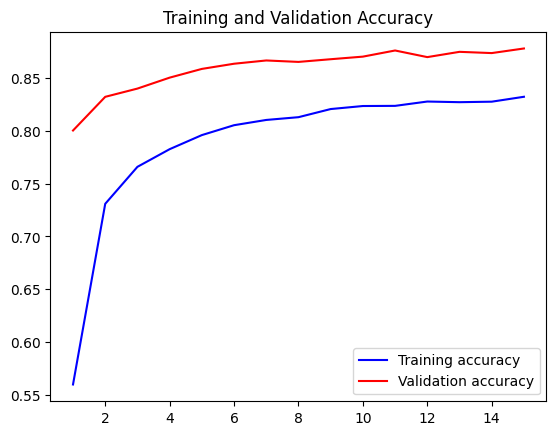

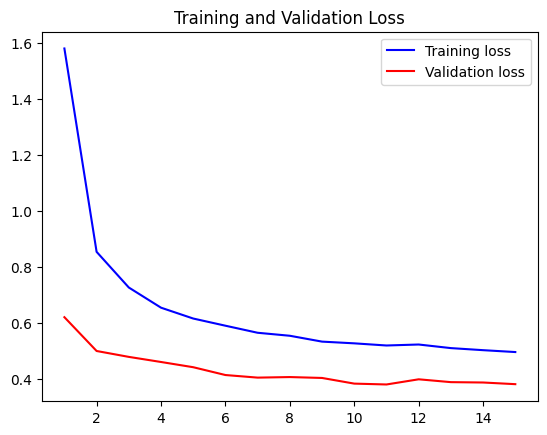

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# 🔹 Accuracy graph
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

# 🔹 Loss graph
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

## Model Evaluation on Validation Data

In [ ]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 347ms/step - accuracy: 0.8781 - loss: 0.3816
Validation Loss: 0.3815900385379791
Validation Accuracy: 0.8781020045280457


## Final Model Evaluation on Test Data

In [ ]:
test_path="/content/drive/MyDrive/Major Project/Final Dataset/val__limited"

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(160, 160),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 11001 images belonging to 55 classes.


In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 352ms/step - accuracy: 0.8781 - loss: 0.3816
Test Loss: 0.38158994913101196
Test Accuracy: 0.8781020045280457


In [ ]:
import numpy as np

test_data.reset()

pred_probs = model.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes


172/172 ━━━━━━━━━━━━━━━━━━━━ 55s 317ms/step


## Confusion Matrix Analysis

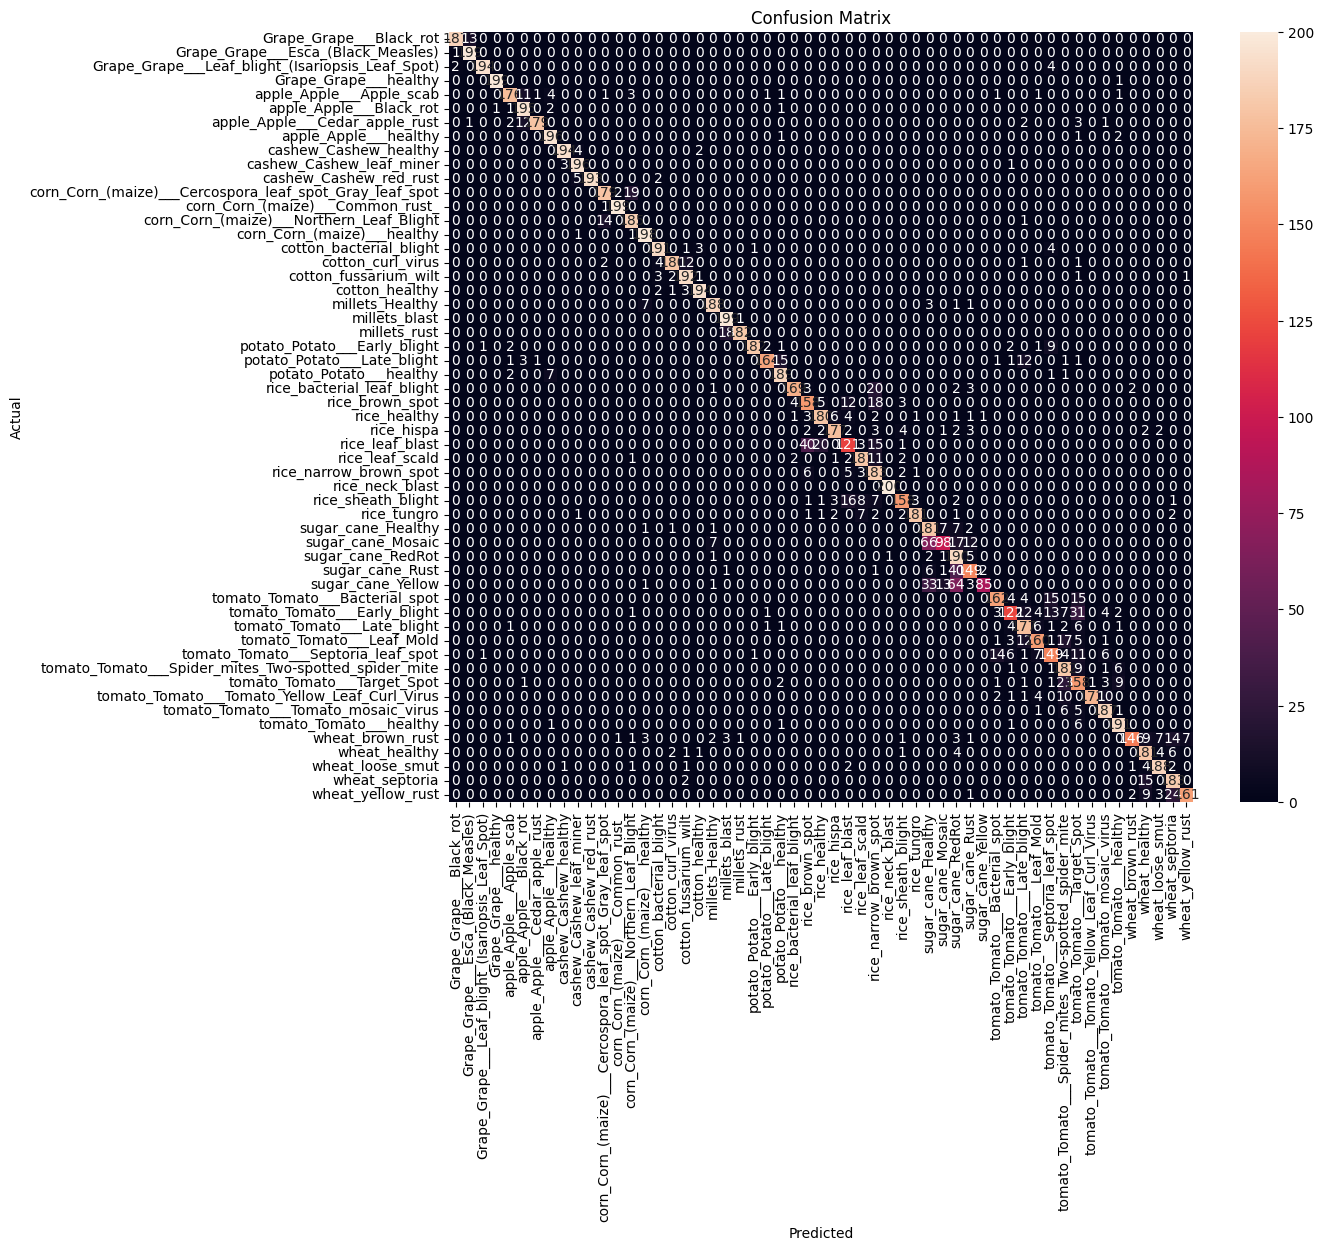

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

class_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

                                                         precision    recall  f1-score   support

                                Grape_Grape___Black_rot       0.98      0.94      0.96       200
                     Grape_Grape___Esca_(Black_Measles)       0.93      0.99      0.96       200
       Grape_Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       0.99      0.97      0.98       200
                                  Grape_Grape___healthy       0.99      0.99      0.99       200
                               apple_Apple___Apple_scab       0.95      0.88      0.91       201
                                apple_Apple___Black_rot       0.88      0.97      0.92       200
                         apple_Apple___Cedar_apple_rust       0.99      0.90      0.94       200
                                  apple_Apple___healthy       0.93      0.98      0.96       200
                                  cashew_Cashew_healthy       0.98      0.97      0.97       200
                             

In [ ]:
model.save("plant_disease_model.keras")

## Conclusion

## Conclusion

In this project, a deep learning-based system was developed to detect and classify plant leaf diseases using image data. The dataset was carefully preprocessed by performing data augmentation, balancing the number of images per class, and removing corrupted images to improve data quality and model performance.

A transfer learning approach was implemented using the MobileNetV2 architecture, which is pre-trained on the ImageNet dataset. By freezing the base layers and adding custom classification layers, the model was able to efficiently learn features relevant to plant disease detection while reducing training time and computational cost.

The model was trained on the training dataset and validated during training to monitor performance. Final evaluation was conducted on a completely unseen test dataset to ensure generalization. The model achieved a test accuracy of **87.81%** with a loss of **0.38**, indicating strong performance across multiple plant disease classes.

Further evaluation using a confusion matrix and classification report showed that the model performs very well on most classes, achieving high precision and recall values. However, some classes such as certain rice, sugarcane, and tomato diseases showed comparatively lower performance, indicating areas for future improvement.

Overall, the proposed system successfully demonstrates the effectiveness of deep learning in automated plant disease detection. This model can serve as a practical tool to assist farmers in early disease identification, helping to reduce crop loss and improve agricultural productivity.

In conclusion, this project highlights the potential of AI-driven solutions in agriculture and provides a scalable foundation for building real-world plant disease detection applications.


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving 1 (71).jpg to 1 (71).jpg


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("plant_disease_model.keras")

In [ ]:
from keras.preprocessing import image
import numpy as np
img = image.load_img('1 (71).jpg', target_size=(160, 160))
img_array=image.img_to_array(img)
img_array=img_array/255.0

In [ ]:
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [ ]:
predictions

array([[9.08597730e-09, 2.13681208e-11, 1.20263344e-09, 6.28972474e-09,
        3.24977151e-07, 2.72853717e-09, 6.50716288e-07, 2.73784713e-06,
        5.67778116e-05, 9.99936461e-01, 1.11916859e-06, 3.69505017e-07,
        3.18113820e-08, 1.78642523e-08, 4.05654852e-08, 3.18473667e-07,
        6.47973835e-08, 1.06637128e-06, 1.20932535e-08]], dtype=float32)

In [ ]:
predicted_class_index = np.argmax(predictions, axis=1)[0]

In [ ]:
predicted_class_index

np.int64(9)

In [ ]:
predicted_label = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

print(f"Prediction: {predicted_label} ({confidence:.2f}%)")

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving 42e774fe-ff8e-4044-8dd5-5deedc64c991___FAM_B.Rot 3148.JPG to 42e774fe-ff8e-4044-8dd5-5deedc64c991___FAM_B.Rot 3148.JPG


In [ ]:
img = image.load_img('done13.jpg', target_size=(160, 160))
img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
print(predicted_class_index)
predicted_label = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

print(f"Prediction: {predicted_label} ({confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
17
Prediction: cotton_fussarium_wilt (97.78%)


In [ ]:
img = image.load_img('7c4ba770-64bf-4cd5-82ea-c5e2a16d81f3___RS_Erly.B 9556.JPG', target_size=(160, 160))
img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
print(predicted_class_index)
predicted_label = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

print(f"Prediction: {predicted_label} ({confidence:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
6
Prediction: apple_Apple___Cedar_apple_rust (36.65%)


In [ ]:
img = image.load_img('42e774fe-ff8e-4044-8dd5-5deedc64c991___FAM_B.Rot 3148.JPG', target_size=(160, 160))
img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
print(predicted_class_index)
predicted_label = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

print(f"Prediction: {predicted_label} ({confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
0
Prediction: Grape_Grape___Black_rot (99.81%)
